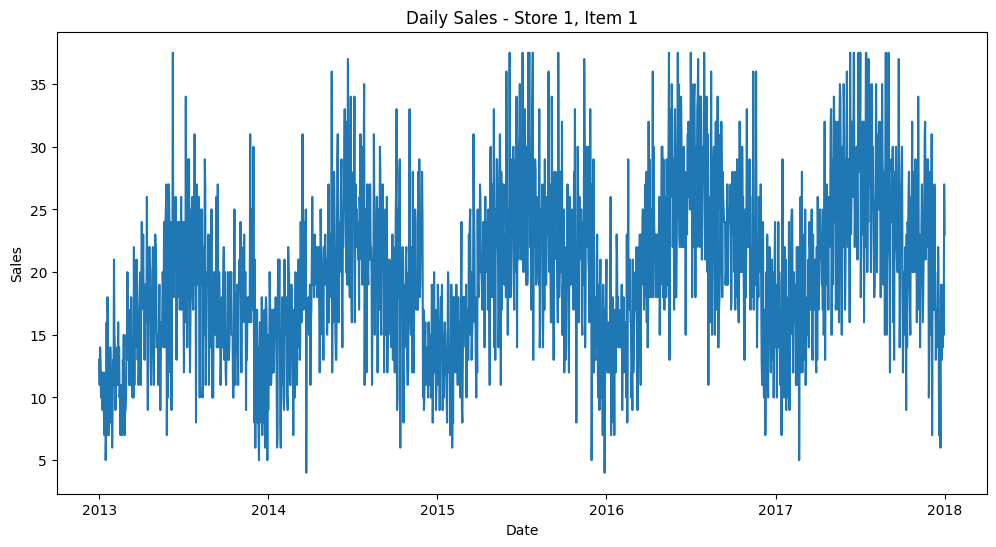

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from smartstock.data.loader import load_raw, filter_series
from smartstock.data.cleaner import clean_series

df = load_raw("../data/raw/train.csv")
s1i1 = filter_series(df, 1, 1)
cleaned = clean_series(s1i1)

plt.figure(figsize=(12, 6))
plt.plot(cleaned.index, cleaned['sales'])
plt.title("Daily Sales - Store 1, Item 1")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

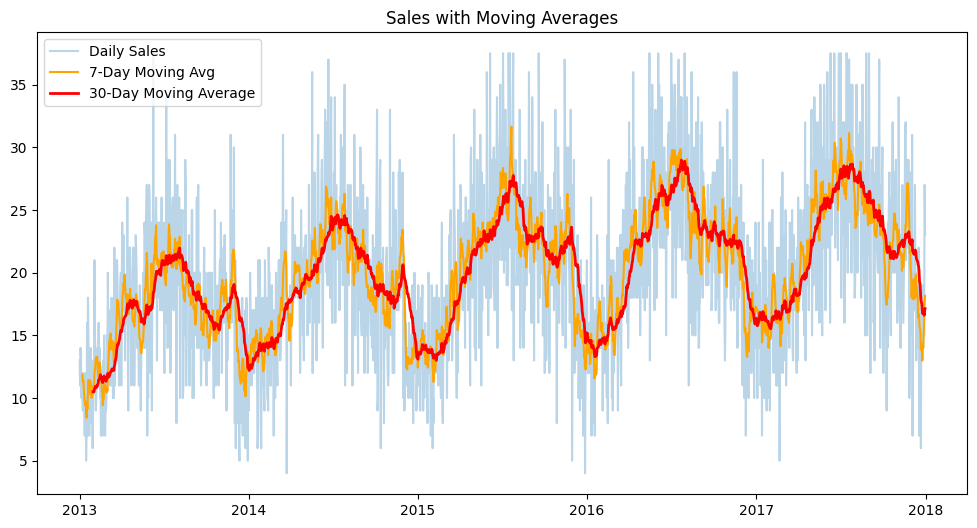

In [3]:
cleaned['MA7'] = cleaned['sales'].rolling(window=7).mean()
cleaned['MA30'] = cleaned['sales'].rolling(window=30).mean()

plt.figure(figsize=(12, 6))
plt.plot(cleaned.index, cleaned['sales'], alpha=0.3, label='Daily Sales')
plt.plot(cleaned.index, cleaned['MA7'], label='7-Day Moving Avg', color='orange')
plt.plot(cleaned.index, cleaned['MA30'], label='30-Day Moving Average', color='red', linewidth=2)
plt.title("Sales with Moving Averages")
plt.legend()
plt.show()

In [4]:
from smartstock.data.features import add_time_features

feat_df = add_time_features(cleaned)

fig = px.box(feat_df, x='day_of_week', y='sales', title='Sales Distribution by Day of Week (0=Mon, 6=Sun)', labels={'day_of_week': 'Day of Week', 'sales': 'Sales Volume'})
fig.show()